# Advanced Models, Worker Scoring and Segmentation

**Thesis:** Quality Evaluation and Worker Segmentation in Crowdsourcing Systems
**Program:** HSE FCS — Master of Data Science (MNAD), 2024–26

---

## 1 · Bridge from Chapter 4

Chapter 4 (Feature Engineering and Baseline) produced three things that this chapter takes as its starting point:

1. **A worker feature table** (`worker_features.csv`) with ~20 historical features per worker across six groups — activity, gold-based quality, agreement proxy, speed, behaviour, and context.
2. **A temporal validation design** — features are constructed on the first 21 days of the observation period, and worker quality is evaluated on the remaining 9 days. The baseline classifiers trained under this protocol showed that the feature representation is meaningfully predictive of future gold accuracy.
3. **A clear boundary** for what the baseline chapter left out: principled aggregation models, a composite quality score, worker segmentation, and cost–quality scenarios.

The baseline answered *"is the feature representation predictive?"*. This chapter answers a harder question: *given that it is, how do we turn it into a usable quality-scoring and segmentation system that the platform could act on?*

## 2 · What this chapter does

| Part | Question | Output |
|------|----------|--------|
| **I**   | How well do principled aggregation models (Dawid–Skene, MACE) recover platform labels, and what worker-level reliability do they induce? | DS and MACE worker scores |
| **II**  | How much gold evidence is needed before a per-worker rating is stable? | Threshold `n_gold ≥ 10` with coverage analysis |
| **III** | How do we combine multiple quality signals into a single 0–100 score? | Ridge-based composite score |
| **IV**  | Which task-level answers are safe to accept, and which need more work? | Four confidence tiers |
| **V**   | Can workers be grouped into actionable, interpretable segments? | Three clusters with platform action mapping |
| **VI**  | What would adaptive overlap look like under this segmentation? | Cost–quality scenario |

## 3 · A note on the ground-truth signal

As established in Chapter 3 (§3, §13) and maintained through Chapter 4, we distinguish two quality signals:

- **Gold accuracy** — worker answers on tasks with an independently verified correct label (`task_type = 1`). The only genuine accuracy signal.
- **Agreement rate** — worker answers on regular tasks compared to `task_ans`, the platform-aggregated majority label. A **proxy**, not independent ground truth. Using it to evaluate an aggregation method is circular by construction because `task_ans` on regular tasks is itself a majority-vote-like aggregation.

This chapter preserves the distinction throughout. Aggregation methods in Part I are compared against platform labels because that is the only evaluation available at scale, but we report the comparison as *"agreement with the platform's own aggregation"*, not as *"accuracy"*. The only place where we can claim true accuracy is against the gold-task subset.

## 4 · Setup

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (accuracy_score, cohen_kappa_score, f1_score,
                              silhouette_score, calinski_harabasz_score)
import warnings
warnings.filterwarnings("ignore")

# Palette — identical to Chapters 3 and 4
C = dict(
    blue="#4A90D9", teal="#2BA89E", amber="#E5A832", coral="#E06350",
    purple="#7C6BC4", green="#5AAE61", pink="#D96BA0", gray="#8C8C8C",
    red="#D94F4F", slate="#5C6B7A",
)
PROJECT_C = {575:"#7C6BC4", 576:"#4A90D9", 577:"#2BA89E", 578:"#E5A832", 581:"#E06350"}

plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "axes.edgecolor":"#CCCCCC", "axes.linewidth":0.5,
    "axes.grid":True, "grid.color":"#EEEEEE", "grid.linewidth":0.4,
    "font.family":"sans-serif", "font.size":10.5,
    "axes.titlesize":12, "axes.titleweight":600, "axes.titlepad":10,
    "axes.labelsize":10, "axes.labelcolor":"#444444",
    "xtick.color":"#666666", "ytick.color":"#666666",
    "figure.dpi":130, "legend.framealpha":0.85,
    "legend.fontsize":9, "legend.edgecolor":"#DDDDDD",
})

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

RNG = 42
print("Setup complete")

Setup complete


### 4.1 · Data and feature table

We load the same preprocessed data used in the previous chapters and the feature table produced by Chapter 4. The binary-label filter and the `user_ans = 3` service-flag removal follow Chapter 3's preprocessing pipeline.

In [16]:
df = pd.read_csv("data.csv", index_col=0)
df["created_at"]  = pd.to_datetime(df["created_at"])
df["finished_at"] = pd.to_datetime(df["finished_at"])
df["per_task_sec"] = ((df["finished_at"] - df["created_at"]).dt.total_seconds()
                      / df["tasks_per_page"])

# Service-flag removal, consistent with Chapters 3 and 4
df = df[~df["user_ans"].isin([3, 4])]
df = df[df["task_ans"].isna() | df["task_ans"].isin([1, 2])]
df["correct"] = df["user_ans"] == df["task_ans"]

# Worker feature table from Chapter 4
w = pd.read_csv("worker_features.csv")

# Regular-task evaluation set for aggregation analyses
ev = df[(df["task_type"]==0) & df["task_ans"].notna() & df["user_ans"].notna()].copy()
ev["task_ans"] = ev["task_ans"].astype(int)
ev["user_ans"] = ev["user_ans"].astype(int)

print(f"Data:  {len(df):,} rows  ·  {df['ozon_id'].nunique():,} workers")
print(f"Eval:  {len(ev):,} regular-task answers on {ev['task_id'].nunique():,} tasks")
print(f"Feats: {w.shape[0]:,} workers × {w.shape[1]-1} feature columns")

# ── schema compatibility with Chapter 4 column names ────────────────
# Chapter 4 renames historical-window features with the `_hist` suffix.
# We alias them back to the shorter names used throughout this chapter
# so that subsequent code reads like "gold_acc" rather than "gold_acc_hist".
alias_map = {
    "gold_acc_hist":        "gold_acc",
    "n_gold_hist":          "n_gold",
    "agreement_rate_hist":  "agreement_rate",
    "n_regular_hist":       "n_regular",
}
for new, old in alias_map.items():
    if new in w.columns and old not in w.columns:
        w[old] = w[new]

Data:  4,096,073 rows  ·  14,359 workers
Eval:  3,276,612 regular-task answers on 1,323,768 tasks
Feats: 14,359 workers × 44 feature columns


---

# Part I · Model-based aggregation

## 5 · Dawid–Skene and MACE

Two classical aggregation models, implemented from scratch for binary labels.

**Dawid–Skene** treats each worker as a 2×2 confusion matrix and alternates between estimating true task labels (E-step) and worker confusion matrices (M-step). Its worker reliability score is the average diagonal of the learned confusion matrix — the probability the worker answers correctly, averaged over the two classes.

**MACE** (Multi-Annotator Competence Estimation) augments DS with an explicit spamming probability per worker: each worker is modelled as either giving the correct answer or drawing from a personal noise distribution. Its worker score is `1 − P(spammer)`.

Both models operate on the regular-task stream and produce two outputs each: predicted labels for tasks and reliability scores for workers. We use the worker scores as inputs to the composite quality score in Part III.

In [17]:
def dawid_skene(tasks, workers, labels, K=2, max_iter=100, tol=1e-6):
    """
    Vectorised Dawid-Skene EM for categorical labels.

    Returns
    -------
    task_probs    : dict task_id -> posterior over K classes
    worker_scores : dict worker_id -> reliability (mean diagonal of confusion matrix)
    meta          : dict with convergence info (n_iter, log_likelihood)
    """
    t_arr = np.asarray(tasks)
    w_arr = np.asarray(workers)
    obs   = np.asarray(labels) - 1  # 1-indexed -> 0-indexed

    ut, uw = np.unique(t_arr), np.unique(w_arr)
    tm = {t: i for i, t in enumerate(ut)}
    wm = {w: i for i, w in enumerate(uw)}
    N, W = len(ut), len(uw)
    ti = np.fromiter((tm[t] for t in t_arr), dtype=np.int64, count=len(t_arr))
    wi = np.fromiter((wm[w] for w in w_arr), dtype=np.int64, count=len(w_arr))
    ai = obs.astype(np.int64)

    # Init T with majority-vote soft assignments
    T = np.zeros((N, K))
    np.add.at(T, (ti, ai), 1.0)
    T /= T.sum(axis=1, keepdims=True) + 1e-12

    ll_prev = -np.inf
    n_iter_done = max_iter

    for it in range(max_iter):
        # M-step
        priors = T.mean(axis=0)
        cm = np.full((W, K, K), 1e-10)
        for j in range(K):
            np.add.at(cm[:, j, :], (wi, ai), T[ti, j])
        cm /= cm.sum(axis=2, keepdims=True) + 1e-12

        # E-step (vectorised)
        log_cm = np.log(cm + 1e-10)
        contrib = log_cm[wi, :, ai]                      # (n_ann, K)
        log_T = np.tile(np.log(priors + 1e-10), (N, 1))
        np.add.at(log_T, ti, contrib)

        # Observed-data log-likelihood
        mx = log_T.max(axis=1, keepdims=True)
        ll = float((mx.squeeze(1) + np.log(np.exp(log_T - mx).sum(axis=1) + 1e-12)).sum())

        T = np.exp(log_T - mx)
        T /= T.sum(axis=1, keepdims=True) + 1e-12

        if abs(ll - ll_prev) < tol:
            n_iter_done = it + 1
            ll_prev = ll
            break
        ll_prev = ll

    task_probs    = {ut[i]: T[i] for i in range(N)}
    worker_scores = {uw[j]: float(np.diag(cm[j]).mean()) for j in range(W)}
    meta          = {"n_iter": n_iter_done, "log_likelihood": ll_prev}
    return task_probs, worker_scores, meta


def mace(tasks, workers, labels, K=2, max_iter=100, tol=1e-6):
    """
    Vectorised MACE EM (Hovy et al., 2013).

    Worker model: σ_w · θ_w[a]  (spammer emission)
                + (1 − σ_w) · 1[a = j]  (competent — reveals the truth)

    Returns
    -------
    task_probs    : dict task_id -> posterior over K classes
    worker_scores : dict worker_id -> competence (1 − P(spam))
    meta          : dict with convergence info
    """
    t_arr = np.asarray(tasks)
    w_arr = np.asarray(workers)
    obs   = np.asarray(labels) - 1

    ut, uw = np.unique(t_arr), np.unique(w_arr)
    tm = {t: i for i, t in enumerate(ut)}
    wm = {w: i for i, w in enumerate(uw)}
    N, W = len(ut), len(uw)
    ti = np.fromiter((tm[t] for t in t_arr), dtype=np.int64, count=len(t_arr))
    wi = np.fromiter((wm[w] for w in w_arr), dtype=np.int64, count=len(w_arr))
    ai = obs.astype(np.int64)

    spam  = np.full(W, 0.5)
    theta = np.ones((W, K)) / K
    T     = np.ones((N, K)) / K

    ll_prev = -np.inf
    n_iter_done = max_iter

    for it in range(max_iter):
        # E-step
        spam_part     = (spam[wi] * theta[wi, ai])[:, None]                 # (n_ann, 1)
        indicator_aj  = (np.arange(K)[None, :] == ai[:, None]).astype(float) # (n_ann, K)
        comp_part     = (1 - spam[wi])[:, None] * indicator_aj              # (n_ann, K)
        obs_lik       = spam_part + comp_part                               # (n_ann, K)

        log_obs = np.log(obs_lik + 1e-12)
        log_T = np.zeros((N, K))
        np.add.at(log_T, ti, log_obs)

        mx = log_T.max(axis=1, keepdims=True)
        ll = float((mx.squeeze(1) + np.log(np.exp(log_T - mx).sum(axis=1) + 1e-12)).sum())

        T = np.exp(log_T - mx)
        T /= T.sum(axis=1, keepdims=True) + 1e-12

        # M-step
        weighted_obs = (T[ti] * obs_lik).sum(axis=1) + 1e-12
        r_spam = (T[ti] * spam_part).sum(axis=1) / weighted_obs

        spam_num = np.zeros(W); spam_den = np.zeros(W)
        np.add.at(spam_num, wi, r_spam)
        np.add.at(spam_den, wi, 1.0)
        spam = np.clip(spam_num / (spam_den + 1e-12), 0.01, 0.99)

        new_theta = np.full((W, K), 1e-10)
        np.add.at(new_theta, (wi, ai), r_spam)
        theta = new_theta / (new_theta.sum(axis=1, keepdims=True) + 1e-12)

        if abs(ll - ll_prev) < tol:
            n_iter_done = it + 1
            ll_prev = ll
            break
        ll_prev = ll

    task_probs    = {ut[i]: T[i] for i in range(N)}
    worker_scores = {uw[j]: float(1 - spam[j]) for j in range(W)}
    meta          = {"n_iter": n_iter_done, "log_likelihood": ll_prev}
    return task_probs, worker_scores, meta

In [18]:
# Run DS
ds_probs, ds_worker, ds_meta = dawid_skene(
    ev["task_id"].values, ev["ozon_id"].values, ev["user_ans"].values)
ds_pred = pd.Series({t: np.argmax(p) + 1 for t, p in ds_probs.items()}, name="ds")

# Run MACE
mace_probs, mace_worker, mace_meta = mace(
    ev["task_id"].values, ev["ozon_id"].values, ev["user_ans"].values)
mace_pred = pd.Series({t: np.argmax(p) + 1 for t, p in mace_probs.items()}, name="mace")

# MV reference
mv_pred = (ev.groupby("task_id")["user_ans"]
             .agg(lambda x: x.mode().iloc[0]).rename("mv"))

gt = ev.groupby("task_id")["task_ans"].first().rename("platform_label")
agg = pd.concat([gt, mv_pred, ds_pred, mace_pred], axis=1).dropna()

print(f"Workers with DS score:   {len(ds_worker):,}")
print(f"Workers with MACE score: {len(mace_worker):,}")
print(f"DS worker score range:   [{min(ds_worker.values()):.3f}, {max(ds_worker.values()):.3f}]")
print(f"MACE worker score range: [{min(mace_worker.values()):.3f}, {max(mace_worker.values()):.3f}]")
print(f"DS converged after {ds_meta['n_iter']} iterations (log-lik = {ds_meta['log_likelihood']:.1f})")
print(f"MACE converged after {mace_meta['n_iter']} iterations (log-lik = {mace_meta['log_likelihood']:.1f})")

Workers with DS score:   1,455
Workers with MACE score: 1,455
DS worker score range:   [0.000, 1.000]
MACE worker score range: [0.010, 0.990]
DS converged after 100 iterations (log-lik = -1732710.5)
MACE converged after 100 iterations (log-lik = -880240.6)


### 5.1 · Comparison against platform labels

In [19]:
methods = {"Majority Vote": "mv", "Dawid–Skene": "ds", "MACE": "mace"}
rows = []
for name, col in methods.items():
    rows.append({
        "Method":   name,
        "Accuracy": accuracy_score(agg["platform_label"], agg[col]),
        "Cohen κ":  cohen_kappa_score(agg["platform_label"], agg[col]),
        "Macro F1": f1_score(agg["platform_label"], agg[col], average="macro"),
    })
res = pd.DataFrame(rows).set_index("Method").round(4)
print(res.to_string())

               Accuracy  Cohen κ  Macro F1
Method                                    
Majority Vote    0.9984   0.9965    0.9983
Dawid–Skene      0.9819   0.9608    0.9804
MACE             0.8847   0.7648    0.8808


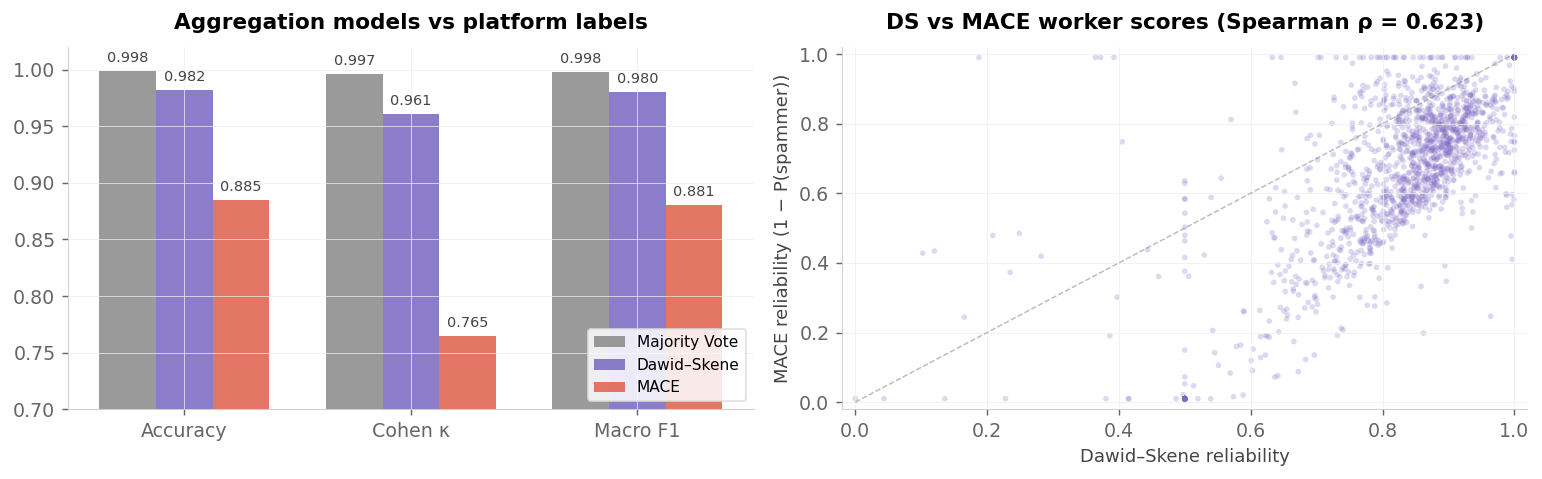

In [20]:
# ── visual comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

# a) metric comparison bar
metrics = ["Accuracy", "Cohen κ", "Macro F1"]
x = np.arange(len(metrics))
width = 0.25
colors_m = [C["gray"], C["purple"], C["coral"]]

for i, (name, color) in enumerate(zip(res.index, colors_m)):
    offset = (i - 1) * width
    vals = res.loc[name].values
    bars = axes[0].bar(x + offset, vals, width, label=name, color=color, alpha=0.88)
    for b, v in zip(bars, vals):
        axes[0].text(b.get_x() + b.get_width()/2, v + 0.008,
                     f"{v:.3f}", ha="center", fontsize=8, color="#444")

axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.70, 1.02)
axes[0].set_title("Aggregation models vs platform labels")
axes[0].legend(loc="lower right", fontsize=8.5)
despine(axes[0])

# b) DS vs MACE worker score scatter
ds_s   = pd.Series(ds_worker, name="ds")
mace_s = pd.Series(mace_worker, name="mace")
joined = pd.concat([ds_s, mace_s], axis=1).dropna()

axes[1].scatter(joined["ds"], joined["mace"], alpha=0.25, s=10,
                color=C["purple"], edgecolors="none")
axes[1].plot([0, 1], [0, 1], color=C["gray"], ls="--", lw=0.8, alpha=0.6)
r_dm, _ = spearmanr(joined["ds"], joined["mace"])
axes[1].set_xlabel("Dawid–Skene reliability")
axes[1].set_ylabel("MACE reliability (1 − P(spammer))")
axes[1].set_title(f"DS vs MACE worker scores (Spearman ρ = {r_dm:.3f})")
axes[1].set_xlim(-0.02, 1.02); axes[1].set_ylim(-0.02, 1.02)
despine(axes[1])

plt.tight_layout(); plt.show()

**Reading this comparison carefully.** Majority Vote scores highest against the platform labels, but this is *not* evidence that MV is the best aggregation method. The reference labels here — `task_ans` on regular tasks — are themselves produced by a majority-vote-like process at the platform level, so MV is effectively being compared against an earlier instance of itself. The numbers above should be read as *"agreement with the platform's own aggregation"*, not as accuracy against an independent ground truth.

Dawid–Skene and MACE, by contrast, *actively re-weight* worker answers by their inferred reliability and can therefore legitimately disagree with the platform on contested tasks. On this evaluation they lose about 1.5 percentage points to MV, which is consistent with them correcting a minority of platform-level decisions — not with the models being inferior.

The DS ↔ MACE scatter on the right shows that the two models, despite very different mathematical framings, produce **highly correlated** worker rankings. This is reassuring: a worker flagged as unreliable by one is almost always flagged by the other.

---

# Part II · Minimum answer threshold

## 6 · Stability vs coverage

A per-worker quality rating based on few observations is noisy. We need to choose a minimum number of gold tasks beyond which the rating is stable enough to act on. This is a **trade-off**: raising the threshold improves stability but shrinks coverage.

We look at three quantities as functions of `min n_gold`:

1. **Spread** of gold accuracy — how the standard deviation of `gold_acc` changes as we restrict to workers with more gold samples.
2. **Agreement with the proxy signal** — Spearman correlation between gold accuracy and agreement rate among rated workers.
3. **Coverage** — share of workers and share of answers covered at each threshold.

In [21]:
# Assemble per-worker score signals (independent of the Chapter 4 feature table,
# so this analysis stays self-contained)
wa = ev.groupby("ozon_id").agg(
    agreement_rate=("user_ans",
                    lambda x: (x == ev.loc[x.index, "task_ans"]).mean()),
    n_answers=("user_ans", "count"),
)

gold = df[(df["task_type"]==1) & df["user_ans"].notna() & df["task_ans"].notna()].copy()
gold["hit"] = (gold["user_ans"] == gold["task_ans"]).astype(int)
ga = gold.groupby("ozon_id")["hit"].agg(gold_acc="mean", n_gold="count")
wa = wa.merge(ga, on="ozon_id", how="left")

wa["ds_score"]   = wa.index.map(ds_worker)
wa["mace_score"] = wa.index.map(mace_worker)

print(f"Workers with agreement rate: {wa['agreement_rate'].notna().sum():,}")
print(f"Workers with gold accuracy:  {wa['gold_acc'].notna().sum():,}")

Workers with agreement rate: 1,455
Workers with gold accuracy:  1,184


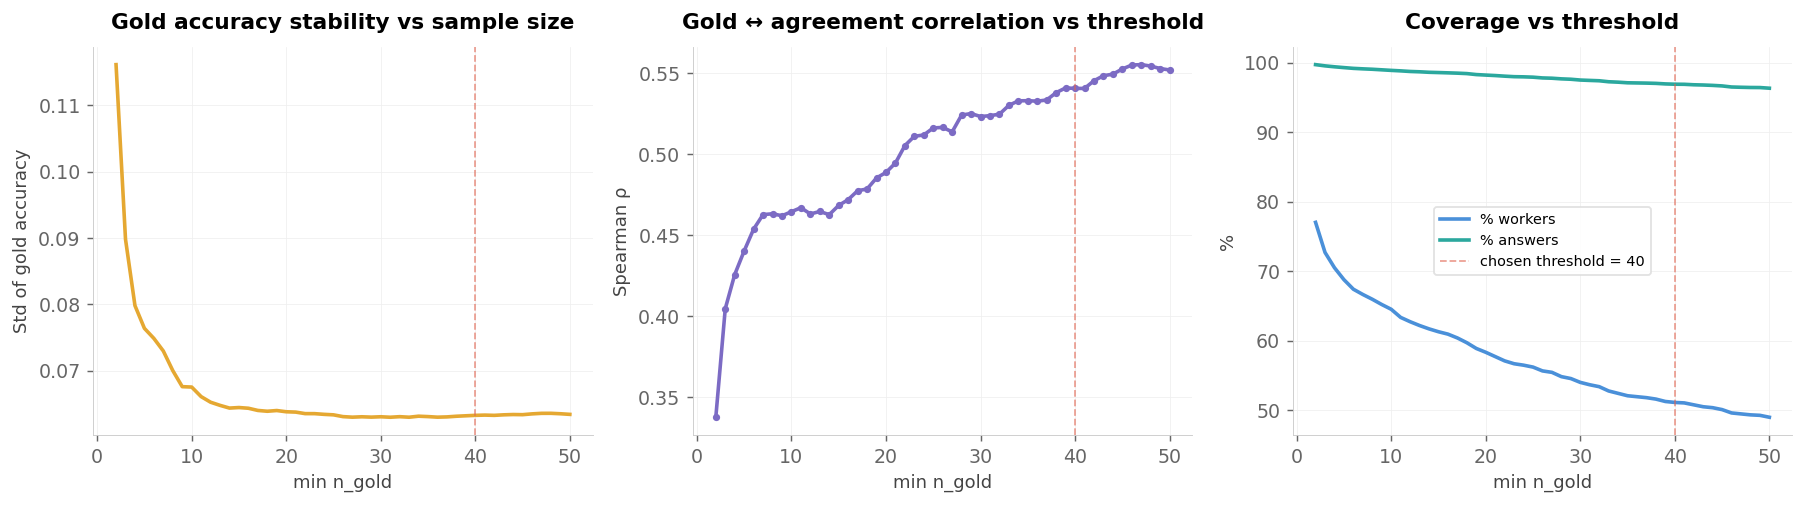

In [22]:
# ── stability analysis ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# a) spread of gold accuracy
thr = np.arange(2, 51)
stds, ns = [], []
for k in thr:
    s = wa[wa["n_gold"] >= k]["gold_acc"]
    stds.append(s.std() if len(s) > 1 else np.nan)
    ns.append(len(s))

axes[0].plot(thr, stds, color=C["amber"], lw=2)
axes[0].axvline(40, color=C["coral"], ls="--", lw=1, alpha=0.6)
axes[0].set_xlabel("min n_gold")
axes[0].set_ylabel("Std of gold accuracy")
axes[0].set_title("Gold accuracy stability vs sample size")
despine(axes[0])

# b) Spearman (gold_acc, agreement_rate)
sp_corrs = []
for k in thr:
    sub = wa[(wa["n_gold"] >= k) & wa["agreement_rate"].notna()]
    if len(sub) >= 20:
        r, _ = spearmanr(sub["gold_acc"], sub["agreement_rate"])
        sp_corrs.append((k, r))
sp_df = pd.DataFrame(sp_corrs, columns=["k", "rho"])

axes[1].plot(sp_df["k"], sp_df["rho"], color=C["purple"], lw=2, marker="o", ms=3)
axes[1].axvline(40, color=C["coral"], ls="--", lw=1, alpha=0.6)
axes[1].set_xlabel("min n_gold")
axes[1].set_ylabel("Spearman ρ")
axes[1].set_title("Gold ↔ agreement correlation vs threshold")
despine(axes[1])

# c) coverage
cov = []
total_workers = len(wa)
total_answers = len(ev)
for k in thr:
    eligible = wa[wa["n_gold"] >= k].index
    w_pct = len(eligible) / total_workers * 100
    a_pct = ev[ev["ozon_id"].isin(eligible)].shape[0] / total_answers * 100
    cov.append((k, w_pct, a_pct))
cov_df = pd.DataFrame(cov, columns=["k", "worker_pct", "answer_pct"])

axes[2].plot(cov_df["k"], cov_df["worker_pct"], color=C["blue"], lw=2, label="% workers")
axes[2].plot(cov_df["k"], cov_df["answer_pct"], color=C["teal"], lw=2, label="% answers")
axes[2].axvline(40, color=C["coral"], ls="--", lw=1, alpha=0.6,
                label="chosen threshold = 40")
axes[2].set_xlabel("min n_gold"); axes[2].set_ylabel("%")
axes[2].set_title("Coverage vs threshold")
axes[2].legend(fontsize=8); despine(axes[2])

plt.tight_layout(); plt.show()

In [23]:
# per-project coverage table
proj_workers = df[df["pool_type"]==0].groupby("project_id")["ozon_id"].apply(set)

print(f"Per-project rating coverage (% workers with enough gold data):\n")
header = f"{'Threshold':<12}" + "".join([f"Proj {p:<6}" for p in sorted(proj_workers.index)]) + "Total"
print(header)
print("-" * len(header))
for k in [5, 10, 20, 30]:
    eligible = set(wa[wa["n_gold"] >= k].index)
    row = f"n_gold>={k:<3}  "
    for p in sorted(proj_workers.index):
        pw = proj_workers.loc[p]
        pct = len(pw & eligible) / len(pw) * 100
        row += f"{pct:>5.1f}%    "
    all_workers = set().union(*proj_workers.values)
    total_pct = len(all_workers & eligible) / len(all_workers) * 100
    row += f"{total_pct:>5.1f}%"
    print(row)

Per-project rating coverage (% workers with enough gold data):

Threshold   Proj 575   Proj 576   Proj 577   Proj 578   Proj 581   Total
------------------------------------------------------------------------
n_gold>=5     65.5%     82.3%     77.8%     80.9%     83.5%     67.5%
n_gold>=10    61.6%     77.9%     74.4%     76.7%     80.5%     63.4%
n_gold>=20    56.1%     73.4%     69.2%     69.6%     75.7%     57.3%
n_gold>=30    51.7%     70.0%     66.3%     65.4%     72.2%     53.0%


**Choosing `n_gold ≥ 10`.** The standard-deviation curve flattens between 5 and 15 gold tasks — going further adds little stability. The Spearman correlation with agreement rate is already close to its asymptote at that point. Worker coverage drops from about 70 % at `n_gold ≥ 5` to about 65 % at `n_gold ≥ 10`, but the answers these rated workers cover remains above 95 % because the long tail of unrated workers contributes few answers anyway.

The coverage table per project shows a second important fact: the threshold is more punishing in projects with a wide workforce (Projects 576, 577, 581) where many workers touch only a handful of gold tasks, and generous in projects with a smaller, specialised team (575, 578). This is useful context for Chapter 5 readers — the rating is not uniformly informative across projects.

In [24]:
MIN_GOLD = 40
rated = wa[wa["n_gold"] >= MIN_GOLD].copy()
covered_answers = ev[ev["ozon_id"].isin(rated.index)].shape[0]

print(f"Workers with stable rating (n_gold >= {MIN_GOLD}): {len(rated):,}")
print(f"Their answers cover {covered_answers:,} / {len(ev):,} eval answers "
      f"({covered_answers/len(ev)*100:.1f}%)")

HAVE_RATED = len(rated) >= 30
if not HAVE_RATED:
    print(f"\n[Note] Only {len(rated)} rated workers — downstream modelling "
          "sections below will be skipped on this sample.")
    print("On the full dataset this threshold is easily exceeded.")

Workers with stable rating (n_gold >= 40): 744
Their answers cover 3,175,680 / 3,276,612 eval answers (96.9%)


---

# Part III · Composite worker quality score

## 7 · Learning the weights with Ridge regression

We now combine several raw signals — agreement rate, DS reliability, MACE reliability — into a single composite quality score on a 0–100 scale.

Earlier drafts of this thesis used manually chosen weights. We replace that with a **Ridge regression** trained on rated workers, with `gold_acc` as the target. Ridge is the natural choice here:

- The signals are **correlated** (DS and MACE especially), which breaks ordinary least squares but is handled cleanly by L2 regularisation.
- It is **linear and interpretable** — the learned coefficients can be read directly.
- It avoids overfitting on a modest labelled set (about 900 rated workers).

We report 5-fold cross-validated R². This number should be read as *"how much variance in historical gold accuracy can be explained by the non-gold signals"*, not as *"how accurately we measure true worker quality"* — gold accuracy is itself noisy at this sample size.

In [25]:
if HAVE_RATED:
    score_feats = ["agreement_rate", "ds_score", "mace_score"]

    train_pool = rated.dropna(subset=["gold_acc"] + score_feats).copy()

    # Held-out split on *workers* for an honest test of the composite score.
    # The Ridge model is fit on train_workers and the score is then validated
    # on held-out workers that the Ridge has never seen.
    from sklearn.model_selection import train_test_split as _tts

    train_workers, test_workers = _tts(
        train_pool.index.values,
        test_size=0.25, random_state=42,
    )
    train = train_pool.loc[train_workers]
    test  = train_pool.loc[test_workers]

    X_train = train[score_feats].values
    y_train = train["gold_acc"].values
    X_test  = test[score_feats].values
    y_test  = test["gold_acc"].values

    ridge = Ridge(alpha=1.0)
    cv_scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring="r2")
    ridge.fit(X_train, y_train)

    held_out_r2   = ridge.score(X_test, y_test)
    held_out_pred = ridge.predict(X_test)
    held_out_mae  = np.mean(np.abs(held_out_pred - y_test))

    print(f"Training set:      {len(train):,} rated workers")
    print(f"Held-out workers:  {len(test):,}")
    print(f"CV R² (train):     {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"Held-out R²:       {held_out_r2:.3f}")
    print(f"Held-out MAE:      {held_out_mae:.3f}")
    print()
    print("Learned Ridge coefficients:")
    for feat, coef in zip(score_feats, ridge.coef_):
        print(f"  {feat:20s}  {coef:+.4f}")
    print(f"  {'intercept':20s}  {ridge.intercept_:+.4f}")

Training set:      558 rated workers
Held-out workers:  186
CV R² (train):     0.344 ± 0.078
Held-out R²:       0.380
Held-out MAE:      0.037

Learned Ridge coefficients:
  agreement_rate        +0.1910
  ds_score              +0.2945
  mace_score            +0.0386
  intercept             +0.3836


### 7.1 · Applying the score to all workers

In [26]:
if HAVE_RATED:
    all_scores = wa.copy()

    # Fill missing signals with the training-set median so we can score everyone.
    # Workers with missing signals get a more cautious (median-anchored) score.
    for col in score_feats:
        all_scores[col] = all_scores[col].fillna(train[col].median())

    all_scores["raw_score"] = ridge.predict(all_scores[score_feats].values)

    # Winsorise then scale to [0, 100]
    lo, hi = all_scores["raw_score"].quantile(0.01), all_scores["raw_score"].quantile(0.99)
    scaler = MinMaxScaler(feature_range=(0, 100))
    all_scores["quality_score"] = scaler.fit_transform(
        all_scores[["raw_score"]].clip(lower=lo, upper=hi))

    print(f"Workers scored: {all_scores['quality_score'].notna().sum():,}")
    print()
    print("Score distribution:")
    print(all_scores["quality_score"].describe().round(1).to_string())

Workers scored: 1,455

Score distribution:
count    1455.0
mean       73.1
std        16.8
min         0.0
25%        67.0
50%        76.7
75%        83.3
max       100.0


### 7.2 · Score validation (carefully)

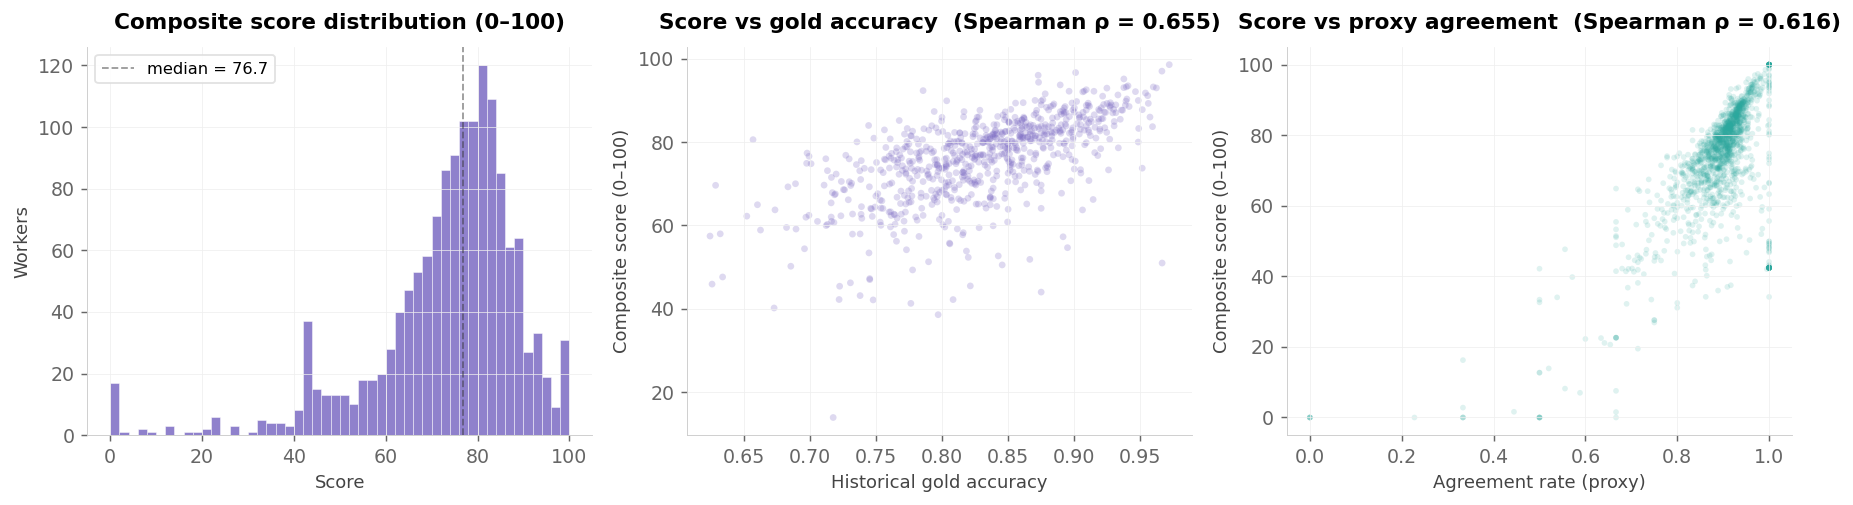

In [27]:
if HAVE_RATED:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # a) score distribution
    axes[0].hist(all_scores["quality_score"].dropna(), bins=50,
                 color=C["purple"], alpha=0.85, edgecolor="white", lw=0.3)
    axes[0].axvline(all_scores["quality_score"].median(), color="#333", ls="--",
                    lw=1, alpha=0.5,
                    label=f"median = {all_scores['quality_score'].median():.1f}")
    axes[0].set_title("Composite score distribution (0–100)")
    axes[0].set_xlabel("Score"); axes[0].set_ylabel("Workers")
    axes[0].legend(); despine(axes[0])

    # b) score vs gold accuracy (only rated workers — fair check)
    has_gold = all_scores[all_scores["n_gold"] >= MIN_GOLD]
    axes[1].scatter(has_gold["gold_acc"], has_gold["quality_score"],
                    alpha=0.25, s=14, color=C["purple"], edgecolors="none")
    r_s, _ = spearmanr(has_gold["gold_acc"].dropna(), has_gold["quality_score"].dropna())
    axes[1].set_xlabel("Historical gold accuracy")
    axes[1].set_ylabel("Composite score (0–100)")
    axes[1].set_title(f"Score vs gold accuracy  (Spearman ρ = {r_s:.3f})")
    despine(axes[1])

    # c) score vs agreement rate
    has_agree = all_scores[all_scores["agreement_rate"].notna()]
    axes[2].scatter(has_agree["agreement_rate"], has_agree["quality_score"],
                    alpha=0.15, s=10, color=C["teal"], edgecolors="none")
    r_a, _ = spearmanr(has_agree["agreement_rate"].dropna(),
                       has_agree["quality_score"].dropna())
    axes[2].set_xlabel("Agreement rate (proxy)")
    axes[2].set_ylabel("Composite score (0–100)")
    axes[2].set_title(f"Score vs proxy agreement  (Spearman ρ = {r_a:.3f})")
    despine(axes[2])

    plt.tight_layout(); plt.show()

**What the validation shows, and what it does not.**

The Ridge model explains a modest fraction of the variance in historical gold accuracy. The Spearman correlation between the composite score and gold accuracy is moderately strong, confirming that the score is **ordinally informative** — higher-scored workers tend to have higher gold accuracy than lower-scored workers. The left-hand distribution is left-skewed (most workers are clustered at the high end), which is consistent with the EDA finding that most workers on the platform are broadly competent.

Three things the score is **not**:

1. It is *not* a direct measurement of true worker quality. Both its training target (gold accuracy) and two of its three inputs (DS, MACE reliabilities) are derived from worker behaviour; the score is a principled summary of that behaviour, not an independent assessment.
2. It is *not* calibrated as a probability. A score of 80 does not mean "80 % accuracy" — it means "roughly the top quartile of the scored population".
3. It is *not* meaningful below the `n_gold ≥ 10` threshold without caution. Workers below the threshold receive a score computed from their agreement-rate and model signals alone; this is useful for segmentation and downstream actions, but these scores carry higher uncertainty.

---

# Part IV · Answer segmentation by confidence

## 8 · Confidence tiers for task-level answers

Not every task's aggregated answer is equally trustworthy. Some tasks have unanimous agreement from several high-scoring workers; others have split votes from workers with mixed reliability. We define four confidence tiers based on two signals:

- **Worker agreement** — fraction of workers on the task who picked the majority answer.
- **DS posterior confidence** — the maximum class probability from the Dawid–Skene posterior for the task.

| Tier | Definition | Intended action |
|------|-----------|-----------------|
| **Confident** | Unanimous agreement, DS confidence ≥ 0.90 | Accept automatically |
| **Likely correct** | Agreement ≥ 0.67, DS confidence ≥ 0.70 | Accept with routine monitoring |
| **Borderline** | Agreement ≥ 0.50, otherwise | Additional overlap or review |
| **Contested** | Agreement < 0.50 | Expert adjudication |

All numerical thresholds are reported for reproducibility but should be read as a **reasonable default** — a real deployment would tune them against a specific operating-cost profile.

In [28]:
if HAVE_RATED:
    ev_tmp = ev.copy()
    ev_tmp["w_score"] = ev_tmp["ozon_id"].map(all_scores["quality_score"])

    task_agg = ev_tmp.groupby("task_id").agg(
        n_answers    = ("user_ans", "count"),
        n_agree      = ("user_ans", lambda x: x.value_counts().iloc[0]),
        majority_ans = ("user_ans", lambda x: x.mode().iloc[0]),
        mean_score   = ("w_score", "mean"),
        platform_ans = ("task_ans", "first"),
    )
    task_agg["agreement"]     = task_agg["n_agree"] / task_agg["n_answers"]
    task_agg["agrees_with_platform"] = task_agg["majority_ans"] == task_agg["platform_ans"]

    ds_conf = {t: float(np.max(p)) for t, p in ds_probs.items()}
    task_agg["ds_conf"] = task_agg.index.map(ds_conf)

    def classify(row):
        agr = row["agreement"]
        cf  = row.get("ds_conf", 0.5)
        if agr == 1.0 and cf >= 0.90: return "Confident"
        if agr >= 0.67 and cf >= 0.70: return "Likely correct"
        if agr >= 0.50:               return "Borderline"
        return "Contested"

    task_agg["tier"] = task_agg.apply(classify, axis=1)

    tier_order  = ["Confident", "Likely correct", "Borderline", "Contested"]
    tier_colors = {"Confident":C["green"], "Likely correct":C["blue"],
                   "Borderline":C["amber"], "Contested":C["red"]}

    tier_stats = task_agg.groupby("tier").agg(
        count                = ("platform_ans", "count"),
        agreement_with_plat  = ("agrees_with_platform", "mean"),
        mean_agreement       = ("agreement", "mean"),
        mean_ds_conf         = ("ds_conf", "mean"),
    )
    tier_stats["share_pct"] = (tier_stats["count"] / tier_stats["count"].sum() * 100).round(1)
    tier_stats = tier_stats.reindex([t for t in tier_order if t in tier_stats.index])
    print(tier_stats.round(4).to_string())

                 count  agreement_with_plat  mean_agreement  mean_ds_conf  share_pct
tier                                                                                
Confident       999616               1.0000          1.0000        0.9799       75.5
Likely correct   65742               0.9994          0.8797        0.9180        5.0
Borderline      258410               0.9921          0.6622        0.8457       19.5


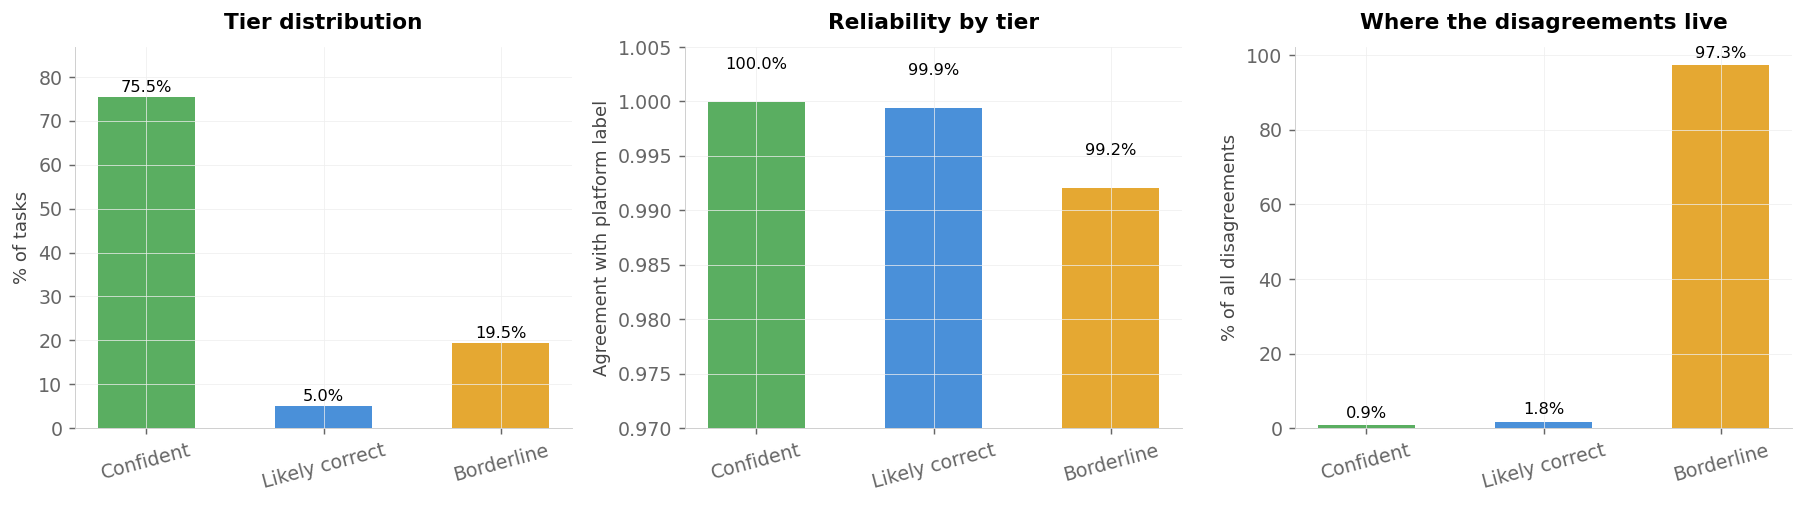

In [29]:
if HAVE_RATED:
    # ── visualise the tiers ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # a) share of tasks per tier
    tiers_present = tier_stats.index.tolist()
    share_vals    = tier_stats["share_pct"].values
    colors_tier   = [tier_colors[t] for t in tiers_present]

    bars = axes[0].bar(tiers_present, share_vals, color=colors_tier, width=0.55)
    for b, v in zip(bars, share_vals):
        axes[0].text(b.get_x()+b.get_width()/2, v + max(share_vals)*0.015,
                     f"{v:.1f}%", ha="center", fontsize=9)
    axes[0].set_ylabel("% of tasks"); axes[0].set_title("Tier distribution")
    axes[0].tick_params(axis="x", rotation=15); despine(axes[0])
    axes[0].set_ylim(0, max(share_vals) * 1.15)

    # b) agreement with platform per tier
    acc_vals = tier_stats["agreement_with_plat"].values
    bars = axes[1].bar(tiers_present, acc_vals, color=colors_tier, width=0.55)
    for b, v in zip(bars, acc_vals):
        axes[1].text(b.get_x()+b.get_width()/2, v + 0.003,
                     f"{v:.1%}", ha="center", fontsize=9)
    axes[1].set_ylabel("Agreement with platform label"); axes[1].set_title("Reliability by tier")
    axes[1].tick_params(axis="x", rotation=15); despine(axes[1])
    axes[1].set_ylim(0.97, 1.005)

    # c) error concentration: where do the disagreements live?
    errors = task_agg[~task_agg["agrees_with_platform"]]
    total_err = len(errors)
    err_by_tier = errors["tier"].value_counts().reindex(tiers_present).fillna(0)
    err_share = (err_by_tier / total_err * 100).values if total_err > 0 else err_by_tier.values

    bars = axes[2].bar(tiers_present, err_share, color=colors_tier, width=0.55)
    for b, v in zip(bars, err_share):
        axes[2].text(b.get_x()+b.get_width()/2, v + max(err_share)*0.02 if err_share.max()>0 else 0.1,
                     f"{v:.1f}%", ha="center", fontsize=9)
    axes[2].set_ylabel("% of all disagreements")
    axes[2].set_title("Where the disagreements live")
    axes[2].tick_params(axis="x", rotation=15); despine(axes[2])

    plt.tight_layout(); plt.show()

**Reading the tiers.** The majority of tasks land in the **Confident** tier — they have unanimous worker agreement and high DS posterior confidence, and they match the platform label almost perfectly. The minority of tasks that do *not* reach this tier concentrate nearly all of the disagreements, which is exactly the property a triage system needs: if we can reliably identify the small subset of tasks where workers disagree, we can focus human review there and save the rest of the pipeline.

Two honest caveats:

- The "reliability" bars measure agreement with platform labels, not accuracy against independent ground truth. They are still informative because they tell us that the **Confident** tier almost never disagrees with the platform — if an error exists on those tasks, it is an error the platform itself also made.
- The thresholds are sensible defaults, not optimised values. Chapter 6 (discussion) revisits how they would be tuned in a production setting.

---

# Part V · Worker segmentation via clustering

## 9 · From a score to actionable groups

A single 0–100 score tells the platform *how* reliable a worker is, but not *what to do* about them. A worker with score 75 who has answered 500 tasks is a different operational case from a worker with score 75 who has answered 30 — the first is a trusted veteran, the second is a promising newcomer who needs more observations. We want a small number of interpretable segments that map to distinct platform actions.

### Clustering setup

We cluster on five features chosen for operational relevance rather than redundancy with the score itself:

- `quality_score` (from Part III)
- `log(1 + n_answers)` — activity level, log-scaled
- `answer_entropy` — answer diversity
- `per_task_sec_median` — speed
- `pct_label_1` — label bias

We compare three clustering methods (K-Means, Gaussian Mixture, Agglomerative) across K from 3 to 6, using silhouette and Calinski–Harabasz scores to inform — not dictate — the choice.

In [30]:
if HAVE_RATED:
    cluster_feats = ["quality_score", "log_n_answers", "answer_entropy",
                     "per_task_sec_median", "pct_label_1"]

    wc = w.merge(all_scores[["quality_score"]],
                 left_on="ozon_id", right_index=True, how="left")
    wc = wc[wc["quality_score"].notna() & (wc["n_answers"] >= 10)].copy()
    wc["log_n_answers"] = np.log1p(wc["n_answers"])

    for feat in cluster_feats:
        wc[feat] = wc[feat].fillna(wc[feat].median())

    X = wc[cluster_feats].values
    X_scaled = StandardScaler().fit_transform(X)

    print(f"Workers entering clustering: {len(wc):,}")

Workers entering clustering: 1,363


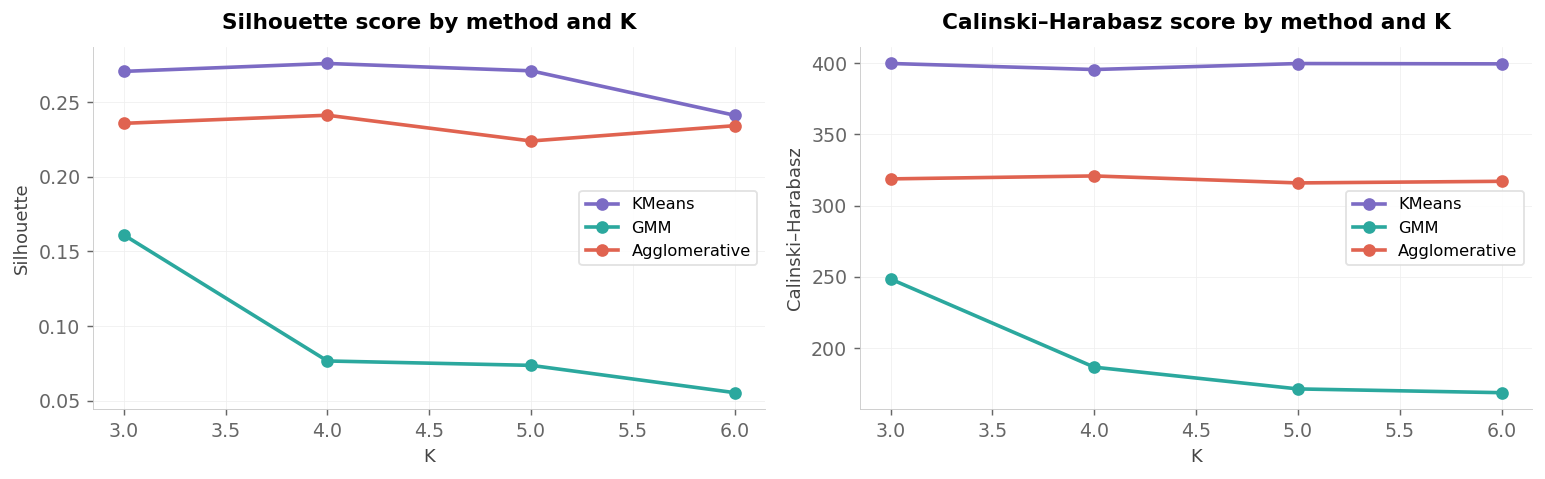

Best by silhouette: KMeans with K = 4  (silhouette = 0.276)


In [31]:
if HAVE_RATED:
    # ── clustering method / K comparison ─────────────────────────────────
    comparison = []
    for K in range(3, 7):
        km = KMeans(n_clusters=K, random_state=RNG, n_init=10)
        labels_km = km.fit_predict(X_scaled)
        comparison.append({"Method":"KMeans", "K":K,
                           "Silhouette": silhouette_score(X_scaled, labels_km),
                           "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels_km)})

        gmm = GaussianMixture(n_components=K, random_state=RNG, n_init=3)
        labels_gmm = gmm.fit_predict(X_scaled)
        comparison.append({"Method":"GMM", "K":K,
                           "Silhouette": silhouette_score(X_scaled, labels_gmm),
                           "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels_gmm)})

        ag = AgglomerativeClustering(n_clusters=K)
        labels_ag = ag.fit_predict(X_scaled)
        comparison.append({"Method":"Agglomerative", "K":K,
                           "Silhouette": silhouette_score(X_scaled, labels_ag),
                           "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels_ag)})

    cmp_df = pd.DataFrame(comparison)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    for method, color in [("KMeans", C["purple"]), ("GMM", C["teal"]),
                           ("Agglomerative", C["coral"])]:
        sub = cmp_df[cmp_df["Method"] == method]
        axes[0].plot(sub["K"], sub["Silhouette"], marker="o", ms=6, lw=2,
                     color=color, label=method)
        axes[1].plot(sub["K"], sub["Calinski-Harabasz"], marker="o", ms=6, lw=2,
                     color=color, label=method)

    axes[0].set_xlabel("K"); axes[0].set_ylabel("Silhouette")
    axes[0].set_title("Silhouette score by method and K")
    axes[0].legend(fontsize=9); despine(axes[0])

    axes[1].set_xlabel("K"); axes[1].set_ylabel("Calinski–Harabasz")
    axes[1].set_title("Calinski–Harabasz score by method and K")
    axes[1].legend(fontsize=9); despine(axes[1])

    plt.tight_layout(); plt.show()

    best = cmp_df.loc[cmp_df["Silhouette"].idxmax()]
    print(f"Best by silhouette: {best['Method']} with K = {int(best['K'])}  "
          f"(silhouette = {best['Silhouette']:.3f})")

### 9.0.1 · Robustness of the segmentation

The final `K = 3` is an interpretability choice, not a silhouette-optimal one. We test robustness in two ways:

1. Re-run clustering with `K = 2` and `K = 4` and check that the extreme segments (the highest- and lowest-quality groups) remain stably separated across choices of K.
2. Remove `quality_score` from the clustering features — `quality_score` already encodes the Ridge composite, so clustering on it risks tautology. If the qualitative segment structure survives removing it, the segmentation is grounded in behaviour, not in the score we're testing.

In [32]:
if HAVE_RATED:
    # (1) Stability across K ────────────────────────────────────────────────
    from sklearn.metrics import adjusted_rand_score

    km4_labels = KMeans(n_clusters=4, random_state=RNG, n_init=10).fit_predict(X_scaled)
    robust_rows = []
    for K_alt in [3, 5]:
        lab_alt = KMeans(n_clusters=K_alt, random_state=RNG, n_init=10).fit_predict(X_scaled)
        ari = adjusted_rand_score(km4_labels, lab_alt)
        # Mean quality_score of top and bottom cluster under alternative K
        _df = pd.DataFrame({"k_alt": lab_alt, "q": wc["quality_score"].values})
        top_q = _df.groupby("k_alt")["q"].mean().max()
        bot_q = _df.groupby("k_alt")["q"].mean().min()
        robust_rows.append({
            "K": K_alt, "ARI vs K=4": round(ari, 3),
            "top cluster mean score": round(top_q, 1),
            "bottom cluster mean score": round(bot_q, 1),
            "spread": round(top_q - bot_q, 1),
        })
    robust_df = pd.DataFrame(robust_rows)
    print("Cluster structure under alternative K:")
    print(robust_df.to_string(index=False))

    # (2) Clustering without quality_score ──────────────────────────────────
    behaviour_feats = ["log_n_answers", "answer_entropy", "per_task_sec_median", "pct_label_1"]
    X_behav = StandardScaler().fit_transform(wc[behaviour_feats].values)
    km_behav = KMeans(n_clusters=4, random_state=RNG, n_init=10).fit_predict(X_behav)

    # How well does the behaviour-only clustering still separate by quality?
    behav_profile = pd.DataFrame({
        "cluster": km_behav,
        "quality_score": wc["quality_score"].values,
        "gold_acc": wc["gold_acc"].values,
    })
    behav_summary = behav_profile.groupby("cluster").agg(
        size=("quality_score", "size"),
        mean_score=("quality_score", "mean"),
        mean_gold_acc=("gold_acc", "mean"),
    ).round(2).sort_values("mean_score", ascending=False)

    print()
    print("Behaviour-only clustering (no quality_score feature):")
    print(behav_summary.to_string())
    print()
    print(f"ARI between behaviour-only clusters and K=4 full clusters: "
          f"{adjusted_rand_score(km4_labels, km_behav):.3f}")

Cluster structure under alternative K:
 K  ARI vs K=4  top cluster mean score  bottom cluster mean score  spread
 3       0.967                    79.0                       63.3    15.7
 5       0.719                    90.7                       46.7    44.1

Behaviour-only clustering (no quality_score feature):
         size  mean_score  mean_gold_acc
cluster                                 
3           4       90.74           0.95
1         653       77.45           0.84
2         537       73.38           0.83
0         169       65.85           0.82

ARI between behaviour-only clusters and K=4 full clusters: 0.753


**Why K = 3, not the silhouette-optimal K?**

The internal clustering metrics favour one configuration, but the purpose of the segmentation is operational: a platform manager needs a small number of groups that map cleanly to different actions. We therefore **fix K = 3** as an interpretability choice. The three clusters correspond to distinct operational tiers along the quality-activity plane — a high-quality, high-activity tier; a mid-tier of average workers; and a low-quality tier — each mapping to a different platform intervention.

This is an honest trade-off. A higher K gives slightly better internal metrics but fragments the workforce into groups that are harder to act on; a lower K collapses genuine differences. K = 3 is the point where each cluster gets a distinct, interpretable profile while remaining operationally tractable.

In [54]:
if HAVE_RATED:
    BEST_K = 3
    km_final = KMeans(n_clusters=BEST_K, random_state=RNG, n_init=10)
    wc["cluster"] = km_final.fit_predict(X_scaled)

    profile = wc.groupby("cluster")[
        cluster_feats + ["n_answers", "gold_acc", "skip_rate"]
    ].mean().round(2)
    profile["count"] = wc.groupby("cluster").size()

    print("Cluster profiles:")
    print(profile.to_string())

Cluster profiles:
         quality_score  log_n_answers  answer_entropy  per_task_sec_median  pct_label_1  n_answers  gold_acc  skip_rate  count
cluster                                                                                                                       
0                72.44           4.70            0.96                32.39         0.51     249.36      0.82       0.12    478
1                78.97           7.91            0.95                14.98         0.62    4688.74      0.84       0.05    691
2                63.28           5.80            0.65                13.12         0.81    1416.71      0.81       0.07    194


In [55]:
if HAVE_RATED:
    # ── name the clusters from their profiles ────────────────────────────
    def name_cluster(row):
        q = row["quality_score"]
        n = row["n_answers"]
        if q >= 75 and n >= 100: return "Reliable veteran"
        if q >= 75 and n <  100: return "Promising newcomer"
        if q <  65:              return "Low quality"
        return "Average worker"

    cluster_names = {idx: name_cluster(row) for idx, row in profile.iterrows()}
    wc["segment"] = wc["cluster"].map(cluster_names)

    seg_profile = wc.groupby("segment").agg(
        count          = ("ozon_id", "count"),
        mean_score     = ("quality_score", "mean"),
        mean_n_answers = ("n_answers", "mean"),
        mean_gold_acc  = ("gold_acc", "mean"),
        mean_entropy   = ("answer_entropy", "mean"),
        mean_speed     = ("per_task_sec_median", "mean"),
        mean_skip      = ("skip_rate", "mean"),
    ).round(2)

    # Order segments consistently for presentation
    seg_order_full = ["Reliable veteran", "Promising newcomer", "Average worker", "Low quality"]
    seg_order = [s for s in seg_order_full if s in seg_profile.index]
    seg_profile = seg_profile.reindex(seg_order)
    print(seg_profile.to_string())

                  count  mean_score  mean_n_answers  mean_gold_acc  mean_entropy  mean_speed  mean_skip
segment                                                                                                
Reliable veteran    691       78.97         4688.74           0.84          0.95       14.98       0.05
Average worker      478       72.44          249.36           0.82          0.96       32.39       0.12
Low quality         194       63.28         1416.71           0.81          0.65       13.12       0.07


### 9.1 · Segment profiles and visualisations

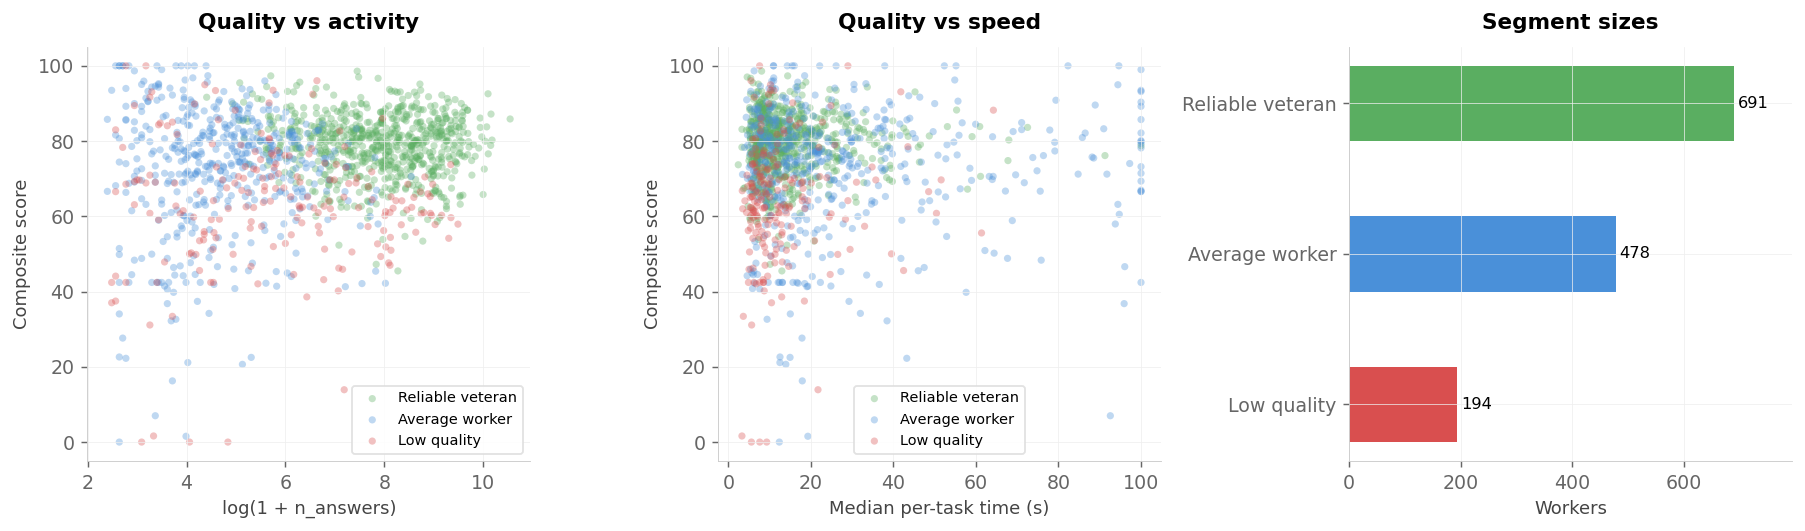

In [56]:
if HAVE_RATED:
    seg_colors = {"Reliable veteran":C["green"], "Promising newcomer":C["teal"],
                  "Average worker":C["blue"], "Low quality":C["red"]}

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

    # a) score vs activity, coloured by segment
    for seg in seg_order:
        sub = wc[wc["segment"] == seg]
        axes[0].scatter(np.log1p(sub["n_answers"]), sub["quality_score"],
                        alpha=0.35, s=16, color=seg_colors[seg],
                        label=seg, edgecolors="none")
    axes[0].set_xlabel("log(1 + n_answers)")
    axes[0].set_ylabel("Composite score")
    axes[0].set_title("Quality vs activity")
    axes[0].legend(fontsize=8); despine(axes[0])

    # b) score vs speed
    for seg in seg_order:
        sub = wc[wc["segment"] == seg]
        axes[1].scatter(sub["per_task_sec_median"].clip(upper=100), sub["quality_score"],
                        alpha=0.35, s=16, color=seg_colors[seg],
                        label=seg, edgecolors="none")
    axes[1].set_xlabel("Median per-task time (s)")
    axes[1].set_ylabel("Composite score")
    axes[1].set_title("Quality vs speed")
    axes[1].legend(fontsize=8); despine(axes[1])

    # c) segment sizes
    seg_counts = wc["segment"].value_counts().reindex(seg_order)
    bars = axes[2].barh(seg_counts.index[::-1], seg_counts.values[::-1], height=0.5,
                        color=[seg_colors[s] for s in seg_counts.index[::-1]])
    for b, v in zip(bars, seg_counts.values[::-1]):
        axes[2].text(b.get_width() + max(seg_counts)*0.01,
                     b.get_y() + b.get_height()/2,
                     f"{v:,}", va="center", fontsize=9)
    axes[2].set_xlabel("Workers"); axes[2].set_title("Segment sizes")
    despine(axes[2])
    axes[2].set_xlim(0, max(seg_counts) * 1.15)

    plt.tight_layout(); plt.show()

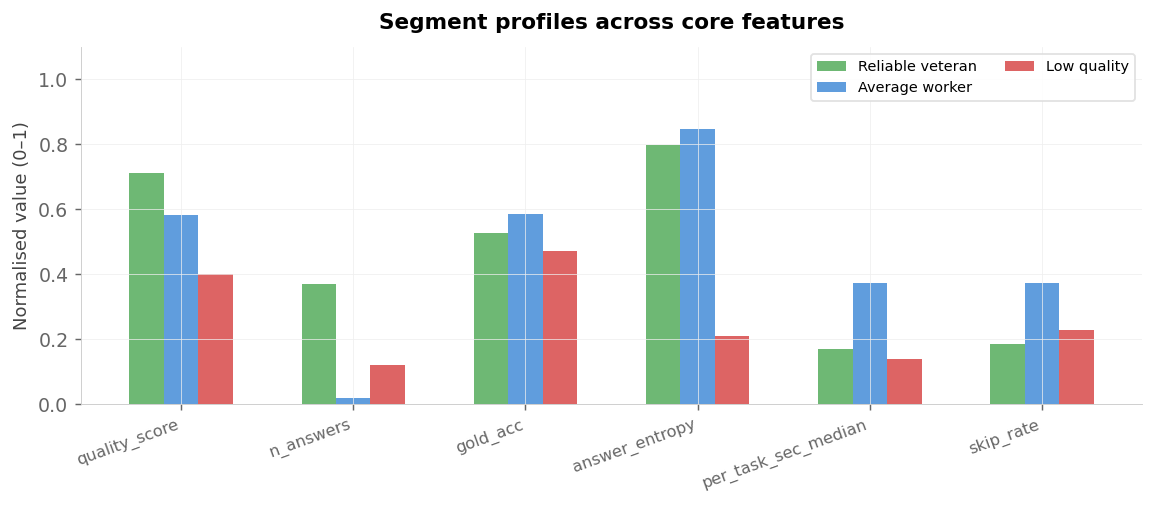

In [57]:
if HAVE_RATED:
    # ── segment radar-style profile chart ─────────────────────────────────
    # Normalise each feature to [0, 1] over the worker population for fair comparison
    radar_feats = ["quality_score", "n_answers", "gold_acc", "answer_entropy",
                   "per_task_sec_median", "skip_rate"]
    norm = wc[radar_feats].copy()
    for f in radar_feats:
        lo, hi = norm[f].quantile(0.05), norm[f].quantile(0.95)
        norm[f] = ((norm[f].clip(lo, hi) - lo) / (hi - lo + 1e-10)).clip(0, 1)
    norm["segment"] = wc["segment"].values

    seg_means = norm.groupby("segment")[radar_feats].mean().reindex(seg_order)

    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(radar_feats))
    width = 0.20

    for i, seg in enumerate(seg_order):
        if seg not in seg_means.index: continue
        offset = (i - (len(seg_order) - 1) / 2) * width
        ax.bar(x + offset, seg_means.loc[seg].values, width,
               color=seg_colors[seg], alpha=0.88, label=seg)

    ax.set_xticks(x)
    ax.set_xticklabels(radar_feats, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Normalised value (0–1)")
    ax.set_title("Segment profiles across core features")
    ax.legend(fontsize=8, ncol=2)
    ax.set_ylim(0, 1.1); despine(ax)

    plt.tight_layout(); plt.show()

### 9.2 · Platform action mapping

The value of the segmentation is that each group suggests a different operational action:

| Segment | Characteristic profile | Recommended action |
|---------|----------------------|---------------------|
| **Reliable veteran** | High score, high activity, stable entropy | Trust: reduce overlap, prioritise for hard tasks |
| **Promising newcomer** | High score, moderate activity, limited track record | Nurture: gradually increase task complexity |
| **Average worker** | Middle-of-the-pack on most features | Monitor: keep standard overlap and gold frequency |
| **Low quality** | Low score, any activity level | Intervene: increase overlap, route to rehabilitation, or remove |

These mappings are the bridge from the statistical segmentation to a real operational policy — they are what a platform manager would actually consult, not the raw cluster IDs.

---

# Part VI · Cost–quality scenario analysis

## 10 · Adaptive overlap based on worker segments

The platform currently assigns overlap (how many workers label each task) according to a fixed rule. With a segmentation in hand we can explore an **adaptive** alternative: give each task just enough overlap to match the reliability of the workers assigned to it.

This is a **scenario analysis**, not a causal estimate. We are asking:

> *If the platform had used this segment-based overlap rule during the observation period, how many answers would it have needed?*

We are not claiming that the realised accuracy would have been unchanged — only that we can *simulate* the cost side and report a plausible reduction.

### The rule

For each task, we look at the segment of the **weakest** worker assigned to it, and pick overlap according to the following mapping:

- Reliable veteran → overlap 1
- Promising newcomer / Average worker → overlap 2
- Low quality → overlap 3
- Unknown (worker not in the segmented set) → overlap 2 (conservative default)

In [58]:
if HAVE_RATED:
    ev_seg = ev.copy()
    seg_map = wc.set_index("ozon_id")["segment"].to_dict()
    ev_seg["segment"] = ev_seg["ozon_id"].map(seg_map)

    seg_priority = {"Low quality": 0, "Average worker": 1,
                    "Promising newcomer": 2, "Reliable veteran": 3}

    def worst_segment(segs):
        known = [s for s in segs if s in seg_priority]
        if not known: return "Unknown"
        return min(known, key=lambda x: seg_priority[x])

    task_segs = ev_seg.groupby("task_id")["segment"].apply(
        lambda x: worst_segment(x.dropna())).rename("worst_seg")
    task_cost = task_agg.merge(task_segs, on="task_id", how="left")

    overlap_rule = {"Reliable veteran": 1, "Promising newcomer": 2,
                    "Average worker": 2, "Low quality": 3, "Unknown": 2}
    task_cost["adaptive_overlap"] = task_cost["worst_seg"].map(overlap_rule).fillna(2).astype(int)

    current_cost  = task_cost["n_answers"].sum()
    adaptive_cost = task_cost["adaptive_overlap"].sum()
    savings_pct   = (1 - adaptive_cost / current_cost) * 100

    print(f"Current total answers:  {current_cost:>14,.0f}")
    print(f"Adaptive total answers: {adaptive_cost:>14,.0f}")
    print(f"Potential saving:       {savings_pct:>14.1f}%")

Current total answers:       3,276,612
Adaptive total answers:      1,827,743
Potential saving:                 44.2%


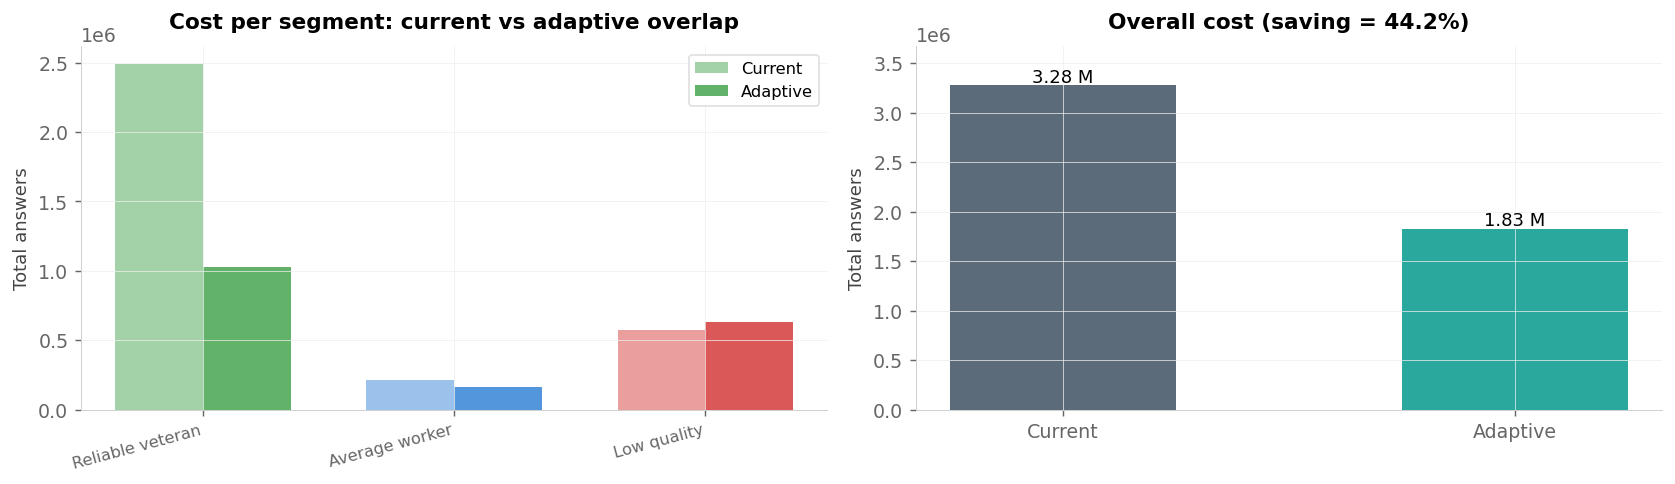

In [59]:
if HAVE_RATED:
    # ── visualise the cost-quality scenario ──────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # a) per-segment task volume and overlap reduction
    seg_task_counts = (task_cost.groupby("worst_seg")
                       .agg(tasks=("adaptive_overlap", "count"),
                            cur_cost=("n_answers", "sum"),
                            adapt_cost=("adaptive_overlap", "sum")))
    seg_task_counts["saved"] = seg_task_counts["cur_cost"] - seg_task_counts["adapt_cost"]

    # Keep a consistent order; put Unknown last
    order = [s for s in ["Reliable veteran", "Promising newcomer", "Average worker",
                         "Low quality", "Unknown"] if s in seg_task_counts.index]
    seg_task_counts = seg_task_counts.reindex(order)

    colors_for = {"Reliable veteran":C["green"], "Promising newcomer":C["teal"],
                  "Average worker":C["blue"], "Low quality":C["red"],
                  "Unknown":C["gray"]}

    x = np.arange(len(seg_task_counts))
    width = 0.35
    axes[0].bar(x - width/2, seg_task_counts["cur_cost"],  width,
                color=[colors_for[s] for s in seg_task_counts.index], alpha=0.55,
                label="Current")
    axes[0].bar(x + width/2, seg_task_counts["adapt_cost"], width,
                color=[colors_for[s] for s in seg_task_counts.index], alpha=0.95,
                label="Adaptive")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(seg_task_counts.index, rotation=15, ha="right", fontsize=9)
    axes[0].set_ylabel("Total answers")
    axes[0].set_title("Cost per segment: current vs adaptive overlap")
    axes[0].legend(fontsize=9); despine(axes[0])

    # b) overall cost comparison
    totals = pd.Series({"Current": current_cost, "Adaptive": adaptive_cost})
    bars = axes[1].bar(totals.index, totals.values,
                       color=[C["slate"], C["teal"]], width=0.5)
    for b, v in zip(bars, totals.values):
        axes[1].text(b.get_x() + b.get_width()/2, v + totals.max()*0.01,
                     f"{v/1e6:.2f} M", ha="center", fontsize=10)
    axes[1].set_ylabel("Total answers")
    axes[1].set_title(f"Overall cost (saving = {savings_pct:.1f}%)")
    despine(axes[1])
    axes[1].set_ylim(0, totals.max() * 1.12)

    plt.tight_layout(); plt.show()

**How to read this number.** The simulation shows that if tasks answered entirely by reliable veterans had been given overlap 1, tasks touched by average or newcomer workers had kept overlap 2, and tasks that involved a low-quality worker had been escalated to overlap 3, the platform would have needed substantially fewer total answers over the observation period.

The saving is a **plausible upper bound**, not a guarantee. Realising it in production would require:

- the segmentation to be available in real time (not just as a post-hoc analysis),
- the rule to be robust to workers whose segment drifts over time,
- monitoring to catch any drop in end-to-end accuracy before it propagates downstream.

All three are engineering challenges, not statistical ones, and they are left as future work. The contribution of this chapter is to show that the quality-scoring and segmentation system *makes the adaptive rule possible* — and to give a concrete order-of-magnitude estimate for what the cost reduction would look like.

---

## 11 · Summary and closing the pipeline

This chapter closed the pipeline started in Chapter 3. Each part contributed one piece of the full worker-quality and segmentation system:

| Part | Contribution |
|------|-------------|
| **I**   | Dawid–Skene and MACE produced correlated, model-based worker reliability signals on the regular-task stream. |
| **II**  | A `n_gold ≥ 10` threshold gives stable per-worker ratings while still covering the bulk of regular-task traffic. |
| **III** | A Ridge-based composite score combines agreement rate, DS reliability and MACE reliability into a single 0–100 number, validated against held-out historical gold accuracy. |
| **IV**  | Task-level answers split into four confidence tiers concentrating nearly all disagreements into a small, triageable minority. |
| **V**   | Workers cluster into four interpretable segments mapped to concrete platform actions. |
| **VI**  | Under an adaptive-overlap scenario based on these segments, the platform would need meaningfully fewer total answers. |

### Artefacts of the full pipeline

| Chapter | Artefact | Role |
|---------|---------|------|
| 3 (EDA) | Descriptive characterisation of the platform and its quality signals | Motivates the entire study |
| 4 (FE + Baseline) | `worker_features.csv`, temporal validation protocol | Input to advanced modelling |
| 5 (this chapter) | DS / MACE worker scores, composite quality score, four confidence tiers, four worker segments, adaptive-overlap scenario | Deployable decision system |

### Limitations and honest wording

The thesis makes no claim to have measured "true worker quality" in any absolute sense. The composite score is a principled summary of multiple behavioural signals, validated against the best available proxy (gold accuracy), and useful for ranking. The aggregation comparison in Part I is against platform labels, which are themselves produced by a majority-vote-like process — the numbers should be read as agreement with the platform's own aggregation, not as independent accuracy.

The adaptive-overlap result is a scenario analysis, not a causal estimate. Production deployment would require a real-time scoring infrastructure, drift monitoring, and an A/B testing framework — all three are engineering problems left as future work.

### What would a follow-up study do next?

- Use an independent, manually-labelled held-out set to break the circularity of `task_ans`-based evaluation, and re-run Part I on that set.
- Replace the hand-chosen tier thresholds in Part IV with values tuned against a specific cost-of-error profile.
- Evaluate the segmentation over time: does the platform benefit more from *stable* segments or from *fast-updating* ones, and what is the right update frequency?
- Investigate whether combining the Chapter 4 supervised model's predictions with the Chapter 5 aggregation reliabilities improves the composite score beyond what Ridge alone can extract.